# CNN Model for Deep Learning - Handwritten Digits Recognition

In [1]:
#Importing the required libraries for modeling
import numpy as np
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
#importing DL libraries for ANN modeling
import tensorflow as tf
from tensorflow import keras
from keras_tqdm import TQDMNotebookCallback

Using TensorFlow backend.


In [3]:
#Loading the Dataset and Splitting them into Train-Test Dependent and Independent Datasets
data_mnist = keras.datasets.mnist
(train_x_full, train_y_full), (test_x, test_y) = data_mnist.load_data()

In [4]:
#Analysing the Datasets
train_x_full.shape

(60000, 28, 28)

In [5]:
test_x.shape

(10000, 28, 28)

In [6]:
train_y_full.shape

(60000,)

In [7]:
test_y.shape

(10000,)

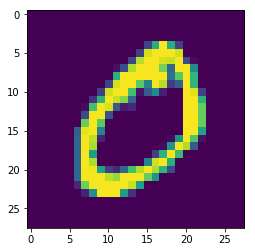

In [8]:
#Viewing the Data
plt.imshow(train_x_full[1])

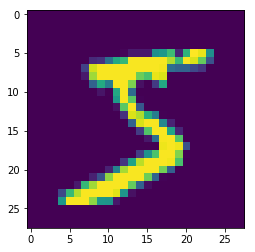

In [9]:
plt.imshow(train_x_full[0])

In [10]:
#Seeing the Ooutput target, Dependent Variable val for above Independent Data Viewed
train_y_full[0]

5

In [11]:
train_y_full[1]

0

### Reshaping the Datasets

In [12]:
train_x_full = train_x_full.reshape((60000,28,28,1))
test_x = test_x.reshape((10000,28,28,1))

### Normalization of the Independent Image Dataset

In [13]:
train_x_n = train_x_full/255.
test_x_n = test_x/255.

### Splitting the Normalized Dataset into Train/Validation/Test Sets as per Problem Description

In [14]:
#Partitioning Train dataset into validation set with 6000 images and rest into a new train, test and valid sets for both Datasets
valid_x, train_x = train_x_n[:6000], train_x_n[6000:]
valid_y, train_y = train_y_full[:6000], train_y_full[6000:]
test_x = test_x_n

In [15]:
#Random Seeding the Model and Datasets for Same Random Data at each run on any machine with this seed value
np.random.seed(42)
tf.random.set_seed(42)

## Building the CNN Models as per problem Description

In [16]:
#Creating both the models as per given Specifications
model_a = keras.models.Sequential()
model_a.add(keras.layers.Conv2D(filters=32, kernel_size = (3, 3), strides=1, activation="relu", padding='valid', input_shape=[28,28,1]))
model_a.add(keras.layers.MaxPooling2D(2,2))
model_a.add(keras.layers.Flatten())
model_a.add(keras.layers.Dense(200, activation="relu"))
model_a.add(keras.layers.Dense(100, activation="relu"))
model_a.add(keras.layers.Dense(10, activation="softmax"))

model_b = keras.models.Sequential()
model_b.add(keras.layers.Conv2D(filters=64, kernel_size = (3, 3), strides=1, activation="relu", padding='valid', input_shape=[28,28,1]))
model_b.add(keras.layers.MaxPooling2D(2,2))
model_b.add(keras.layers.Flatten())
model_b.add(keras.layers.Dense(200, activation="relu"))
model_b.add(keras.layers.Dense(100, activation="relu"))
model_b.add(keras.layers.Dense(10, activation="softmax"))

In [17]:
model_a.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 26, 26, 32)        320       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 13, 13, 32)        0         
_________________________________________________________________
flatten (Flatten)            (None, 5408)              0         
_________________________________________________________________
dense (Dense)                (None, 200)               1081800   
_________________________________________________________________
dense_1 (Dense)              (None, 100)               20100     
_________________________________________________________________
dense_2 (Dense)              (None, 10)                1010      
Total params: 1,103,230
Trainable params: 1,103,230
Non-trainable params: 0
______________________________________________

In [18]:
model_b.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 26, 26, 64)        640       
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 13, 13, 64)        0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 10816)             0         
_________________________________________________________________
dense_3 (Dense)              (None, 200)               2163400   
_________________________________________________________________
dense_4 (Dense)              (None, 100)               20100     
_________________________________________________________________
dense_5 (Dense)              (None, 10)                1010      
Total params: 2,185,150
Trainable params: 2,185,150
Non-trainable params: 0
____________________________________________

### Compiling the Models

In [19]:
model_a.compile(loss="sparse_categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])
model_b.compile(loss="sparse_categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

### Training the models for 60 epochs

In [20]:
#Training the 1st Model, using verbose=0 for no timeouts, silent op lines, 2 for one line per epoch, during fitting and training of the notebook
model_a_history = model_a.fit(train_x, train_y, epochs=60, verbose=2, validation_data=(valid_x, valid_y))

Train on 54000 samples, validate on 6000 samples
Epoch 1/60
54000/54000 - 39s - loss: 0.5195 - accuracy: 0.8555 - val_loss: 0.2253 - val_accuracy: 0.9358
Epoch 2/60
54000/54000 - 34s - loss: 0.2069 - accuracy: 0.9386 - val_loss: 0.1664 - val_accuracy: 0.9482
Epoch 3/60
54000/54000 - 33s - loss: 0.1514 - accuracy: 0.9551 - val_loss: 0.1268 - val_accuracy: 0.9612
Epoch 4/60
54000/54000 - 36s - loss: 0.1224 - accuracy: 0.9631 - val_loss: 0.1194 - val_accuracy: 0.9658
Epoch 5/60
54000/54000 - 36s - loss: 0.1042 - accuracy: 0.9680 - val_loss: 0.1223 - val_accuracy: 0.9637
Epoch 6/60
54000/54000 - 33s - loss: 0.0913 - accuracy: 0.9718 - val_loss: 0.0819 - val_accuracy: 0.9743
Epoch 7/60
54000/54000 - 36s - loss: 0.0800 - accuracy: 0.9754 - val_loss: 0.0885 - val_accuracy: 0.9740
Epoch 8/60
54000/54000 - 42s - loss: 0.0718 - accuracy: 0.9774 - val_loss: 0.0734 - val_accuracy: 0.9780
Epoch 9/60
54000/54000 - 41s - loss: 0.0638 - accuracy: 0.9804 - val_loss: 0.0803 - val_accuracy: 0.9762
Epoch 

#### Saving the first model built and trained so far in %pwd - present working directory

In [21]:
%pwd

'C:\\Users\\Manish Gupta'

In [22]:
model_a.save("HandwritingRecogCNN-Model-A.h5")

### Training the Second Model as per problem Specs

In [23]:
#Training the 2d Model, using verbose=0 for no timeouts, silent op lines, 2 for one line per epoch, during fitting and training of the notebook
model_b_history = model_b.fit(train_x, train_y, epochs=60, verbose=2, validation_data=(valid_x, valid_y))

Train on 54000 samples, validate on 6000 samples
Epoch 1/60
54000/54000 - 61s - loss: 0.4852 - accuracy: 0.8684 - val_loss: 0.2257 - val_accuracy: 0.9378
Epoch 2/60
54000/54000 - 61s - loss: 0.2050 - accuracy: 0.9384 - val_loss: 0.1744 - val_accuracy: 0.9453
Epoch 3/60
54000/54000 - 58s - loss: 0.1510 - accuracy: 0.9545 - val_loss: 0.1310 - val_accuracy: 0.9618
Epoch 4/60
54000/54000 - 59s - loss: 0.1212 - accuracy: 0.9634 - val_loss: 0.1204 - val_accuracy: 0.9653
Epoch 5/60
54000/54000 - 58s - loss: 0.1024 - accuracy: 0.9687 - val_loss: 0.1031 - val_accuracy: 0.9683
Epoch 6/60
54000/54000 - 60s - loss: 0.0884 - accuracy: 0.9731 - val_loss: 0.0839 - val_accuracy: 0.9727
Epoch 7/60
54000/54000 - 58s - loss: 0.0779 - accuracy: 0.9763 - val_loss: 0.0896 - val_accuracy: 0.9712
Epoch 8/60
54000/54000 - 60s - loss: 0.0696 - accuracy: 0.9784 - val_loss: 0.0757 - val_accuracy: 0.9770
Epoch 9/60
54000/54000 - 57s - loss: 0.0623 - accuracy: 0.9804 - val_loss: 0.0809 - val_accuracy: 0.9750
Epoch 

#### Saving the second model built and trained so far in %pwd - present working directory

In [24]:
model_b.save("HandwritingRecogCNN-Model-B.h5")

### Plotting the Model Curve

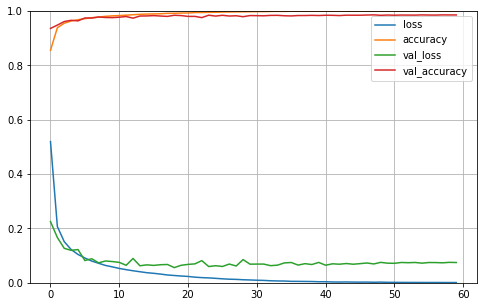

In [25]:
#Plotting curve to see model A Convergence and finding best possible modeling epoch
pd.DataFrame(model_a_history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

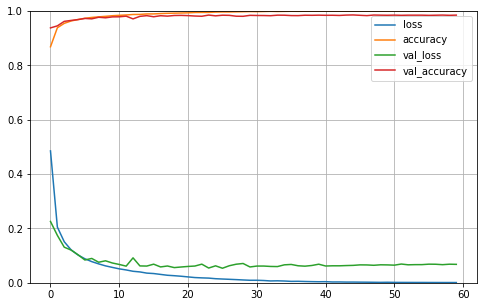

In [26]:
#Plotting curve to see model B Convergence and finding best possible modeling epoch
pd.DataFrame(model_b_history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

## Evaluating the Model on Test data

In [27]:
#evaluation of 1st Model - A
ev1 = model_a.evaluate(test_x, test_y)

10000/1 [===============================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================

In [28]:
#Displaying loss and accuracy in ev
ev1

[0.06004434397873747, 0.9842]

In [29]:
#evaluation of 1st Model - B
ev2 = model_b.evaluate(test_x, test_y)

10000/1 [===============================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================

In [30]:
#Displaying loss and accuracy in ev2
ev2

[0.058243859440924396, 0.9869]

### Predicting values of 5 test records, using them as a new alias

In [31]:
new_x = test_x[:5]

In [33]:
#Predicting and Comparing first 5 predicted and actual tesalues by model - A
pred_y = model_a.predict(new_x)
print(pred_y)
print(test_y[:5])

[[1.10820001e-12 1.03432721e-10 7.30307315e-10 3.55859053e-09
  1.97118385e-12 1.01166418e-15 1.23034634e-20 1.00000000e+00
  2.35308057e-13 2.89389596e-10]
 [1.05409290e-12 1.25895072e-10 1.00000000e+00 6.97793082e-12
  3.66558099e-18 2.42563204e-17 4.82770346e-16 1.03293507e-18
  1.54957800e-11 1.26225590e-19]
 [7.59648344e-10 9.99995828e-01 1.81600757e-09 4.68745487e-10
  7.30234319e-07 5.41718004e-10 4.51412383e-08 2.56781550e-06
  8.44226861e-07 3.27749772e-11]
 [1.00000000e+00 5.81051591e-13 7.50218290e-11 6.32352277e-15
  8.89731539e-14 7.29760696e-12 3.37178534e-08 5.84722437e-10
  1.01551913e-15 5.08910518e-11]
 [1.51719762e-10 9.11440867e-10 2.80908408e-10 6.38343140e-16
  9.99999881e-01 8.98102935e-14 2.66995714e-09 2.28919106e-09
  2.15019443e-11 8.49424353e-08]]
[7 2 1 0 4]


In [34]:
#Predicting and Comparing first 5 predicted and actual tesalues by model - B
pred_y = model_b.predict(new_x)
print(pred_y)
print(test_y[:5])

[[3.5957385e-14 2.8599584e-13 1.0505923e-12 1.3179989e-09 4.4332116e-15
  5.6829066e-19 2.3197882e-16 1.0000000e+00 9.7855811e-16 1.0304819e-09]
 [2.6174276e-16 4.8801997e-11 1.0000000e+00 3.6424674e-12 1.6717538e-24
  1.3097113e-21 1.7683591e-17 9.7534365e-20 1.8236625e-12 2.5513298e-23]
 [1.7142619e-10 9.9996531e-01 4.8884502e-08 1.3939458e-10 6.8520188e-07
  1.0278042e-09 1.3245212e-08 3.1698481e-05 2.2875092e-06 1.8821911e-11]
 [1.0000000e+00 1.2006538e-13 9.0807591e-11 1.4818497e-12 3.2513586e-12
  3.9826072e-12 1.1900346e-08 5.2578591e-10 5.9906918e-15 1.1650944e-10]
 [5.0176963e-12 1.9912665e-12 4.1966027e-12 1.8225453e-15 9.9999905e-01
  1.4756325e-15 1.5836348e-09 5.1784497e-07 3.1792123e-13 5.1420869e-07]]
[7 2 1 0 4]


## Created, Developed, Designed and Manifested by - Manish Gupta ©